# Лабораторная работа №3

Цель лабораторной работы: изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, RepeatedKFold, LeaveOneOut, LeavePOut, ShuffleSplit, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve
%matplotlib inline 
sns.set(style="ticks")

## Задание

* Выберите набор данных (датасет) для решения задачи классификации или регрессии.
* В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
* С использованием метода train_test_split разделите выборку на обучающую и тестовую.
* Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
* Произведите подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
* Сравните метрики качества исходной и оптимальной моделей.

## Датасет

Для решения задачи выберем датасет системы распознавания букв латинского алфавита: [ссылка](https://archive.ics.uci.edu/dataset/59/letter+recognition).

Для удобства в файл letter-recognition.data были добавлены заголовки столбцов.

In [4]:
data = pd.read_csv('data/letter_recognition/letter-recognition.csv', sep=",")

In [6]:
# Форма датасета

data.shape

(20000, 17)

In [8]:
# Статистика по датасету

data.describe()

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


In [9]:
# Первые 5 строк

data.head()

,lettr,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


Целевой признак - lettr, то есть распознанная заглавная буква латинского алфавита. Разнесем целевые и нецелевые признаки по разным объектам.

In [10]:
target = data['lettr']
data = data.drop('lettr', axis=1)

## Разбиение датасета

Разобьем данные на две выборки: обучающую и тестовую. Пропорция: 1/5 - тестовые данные, 4/5 - обучающие.

In [14]:
# Разделение выборки на обучающую и тестовую
# Стратификация используется для сохранения распределения
letter_X_train, letter_X_test, letter_y_train, letter_y_test = train_test_split(
    data, target, test_size=0.2, random_state=1, stratify=target)

## Модель ближайших соседей для произвольно заданного гиперпараметра K

In [15]:
# 5 ближайших соседей
cl1_1 = KNeighborsClassifier(n_neighbors=5)
cl1_1.fit(letter_X_train, letter_y_train)
target1_0 = cl1_1.predict(letter_X_train)
target1_1 = cl1_1.predict(letter_X_test)
accuracy_score(letter_y_train, target1_0), accuracy_score(letter_y_test, target1_1)

(0.97575, 0.9495)

Точность модели ближайших соседей с K = 5 для обучающей выборки: 97,58%, для тестовой: 94,95%. Использованная метрика - accuracy_score, то есть доля верных предсказаний.

## Подбор гиперпараметра K

Попробуем оптимизировать модель, подобрав значение гиперпараметра K разными методами. Для каждого метода будем использовать свою стратегию кросс-валидации. Сначала используем GridSearchCV.

In [41]:
# Перебираемые параметры
n_range = np.array(range(2,12,1))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11])}]

In [42]:
# Первая стратегия кросс-валидации: StratifiedKFold - сохраняет баланс классов
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [43]:
%%time
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=cv_stratified, scoring='accuracy')
clf_gs.fit(letter_X_train, letter_y_train)

CPU times: total: 1min 6s
Wall time: 43.7 s


,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': array([ 2, 3..., 9, 10, 11])}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(3)


In [44]:
clf_gs.cv_results_

{'mean_fit_time': array([0.01452947, 0.01370983, 0.0131721 , 0.01377645, 0.01526594,
        0.01711035, 0.01602259, 0.01797624, 0.01358919, 0.01302886]),
 'std_fit_time': array([0.00273902, 0.00173169, 0.00053333, 0.00116335, 0.0033305 ,
        0.00390326, 0.00412788, 0.00517272, 0.00120767, 0.00040774]),
 'mean_score_time': array([0.84137454, 0.81851521, 0.85773859, 0.85222874, 0.84356837,
        0.92393522, 0.87110066, 0.89749079, 0.81939874, 0.84459901]),
 'std_score_time': array([0.04222131, 0.02276784, 0.02989487, 0.05285758, 0.05272604,
        0.05399592, 0.08760546, 0.06660814, 0.04937849, 0.03437683]),
 'param_n_neighbors': masked_array(data=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=999999),
 'params': [{'n_neighbors': np.int64(2)},
  {'n_neighbors': np.int64(3)},
  {'n_neighbors': np.int64(4)},
  {'n_neighbors': np.int64(5)},
  {'n_neighbors': np.int64(

In [45]:
# Лучшая модель
clf_gs.best_estimator_

,n_neighbors,np.int64(3)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
# Лучшее значение метрики
clf_gs.best_score_

np.float64(0.9455)

In [47]:
# Лучшее значение параметров
clf_gs.best_params_

{'n_neighbors': np.int64(3)}

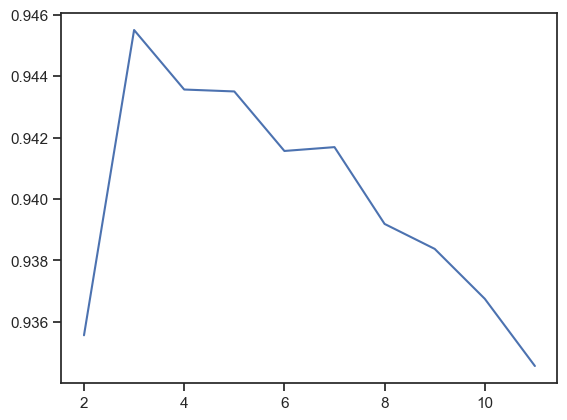

In [48]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])

Теперь используем метод Randomized Search.

In [49]:
# Вторая стратегия кросс-валидации: обычный KFold
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [50]:
%%time
clf_rs = RandomizedSearchCV(KNeighborsClassifier(), tuned_parameters, cv=cv_kfold, scoring='accuracy')
clf_rs.fit(letter_X_train, letter_y_train)

CPU times: total: 1min 5s
Wall time: 43.6 s


,estimator,KNeighborsClassifier()
,param_distributions,"[{'n_neighbors': array([ 2, 3..., 9, 10, 11])}]"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [51]:
# В данном случае оба способа нашли одинаковое решение
clf_rs.best_score_, clf_rs.best_params_

(np.float64(0.946125), {'n_neighbors': np.int64(3)})

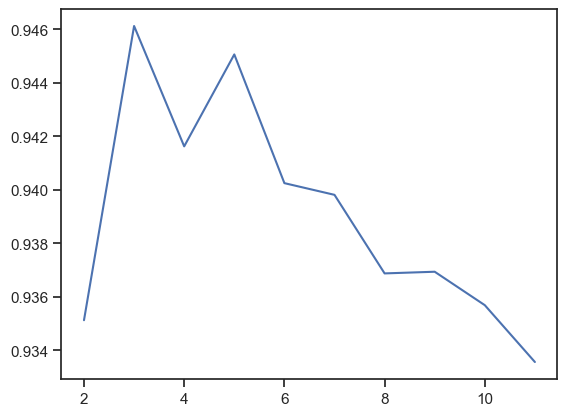

In [52]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_rs.cv_results_['mean_test_score'])

## Сравнение метрик качества исходной и оптимальной моделей.

Перебор значений K привел нас к значению 3. Это довольно низкое значение - имеется риск переобучения. 

Проведем прямое сравнение метрик качества между исходной и оптимальной моделями.

In [55]:
# Исходная модель
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(letter_X_train, letter_y_train)
y_train_pred_base = knn_base.predict(letter_X_train)
y_test_pred_base = knn_base.predict(letter_X_test)

# Оптимальная модель
knn_optimal = KNeighborsClassifier(n_neighbors=clf_gs.best_params_['n_neighbors'])
knn_optimal.fit(letter_X_train, letter_y_train)
y_train_pred_opt = knn_optimal.predict(letter_X_train)
y_test_pred_opt = knn_optimal.predict(letter_X_test)

In [59]:
# Сбор метрик
metrics = {
    'Accuracy': [accuracy_score, None],
    'Precision (macro)': [precision_score, {'average': 'macro'}],
    'Recall (macro)': [recall_score, {'average': 'macro'}],
    'F1-score (macro)': [f1_score, {'average': 'macro'}],
}

print("=" * 80)
print(f"{'Метрика':<20} {'Исходная (K=5)':<30} {'Оптимальная (K=' + str(clf_gs.best_params_['n_neighbors']) + ')':<30}")
print("=" * 80)

for metric_name, (metric_func, kwargs) in metrics.items():
    if kwargs is None:
        train_base = metric_func(letter_y_train, y_train_pred_base)
        test_base = metric_func(letter_y_test, y_test_pred_base)
        train_opt = metric_func(letter_y_train, y_train_pred_opt)
        test_opt = metric_func(letter_y_test, y_test_pred_opt)
    else:
        train_base = metric_func(letter_y_train, y_train_pred_base, **kwargs)
        test_base = metric_func(letter_y_test, y_test_pred_base, **kwargs)
        train_opt = metric_func(letter_y_train, y_train_pred_opt, **kwargs)
        test_opt = metric_func(letter_y_test, y_test_pred_opt, **kwargs)
    
    print(f"{metric_name:<20} Train: {train_base:.4f} | Test: {test_base:.4f}    Train: {train_opt:.4f} | Test: {test_opt:.4f}")

Метрика              Исходная (K=5)                 Оптимальная (K=3)             
Accuracy             Train: 0.9758 | Test: 0.9495    Train: 0.9826 | Test: 0.9463
Precision (macro)    Train: 0.9758 | Test: 0.9502    Train: 0.9826 | Test: 0.9473
Recall (macro)       Train: 0.9756 | Test: 0.9491    Train: 0.9824 | Test: 0.9459
F1-score (macro)     Train: 0.9757 | Test: 0.9493    Train: 0.9825 | Test: 0.9462


Способы подбора K дали нам модель, на практике уступающие модели с произвольно подобранным K = 5. Ухудшение параметров незначительно, но риск переобучения скорее оправдался - улучшение всех метрик по обучающей выборке сопровождается ухудшением по тестовой. Это свидетельствует о необходимости проявления осторожности в подборке стратегий кросс-валидации.